<a href="https://colab.research.google.com/github/GUNAPILLCO/neural_profit/blob/main/3_dise%C3%B1o_entrenamiento_evaluacion/3_2_modelo_xgboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3.2. Primer modelo

## 0. Clonado de repositorio, importación de librerías y carga del dataset

### Clonado de repositorio e importación de librerías

In [18]:
#Clonamos el repo
#LINK DE REPOSITORIO: https://github.com/GUNAPILLCO/neural_profit

!git clone https://github.com/GUNAPILLCO/neural_profit.git

fatal: destination path 'neural_profit' already exists and is not an empty directory.


In [19]:
import sys
import warnings
warnings.filterwarnings('ignore')

# 📦 Instalación de librerías necesarias (una sola vez)
# !{sys.executable} -m pip install -q pandas_market_calendars  # Solo si usás horarios de mercados
!{sys.executable} -m pip install -q ta
!{sys.executable} -m pip install -q xgboost==1.7.6  # Versión compatible con early_stopping_rounds

print("Librerías instaladas: ta, xgboost") # versión estable que soporta early_stopping_rounds y callbacks

Librerías instaladas: ta, xgboost


In [20]:
# Utilidades del sistema y fechas
import os
import glob
import requests
from datetime import datetime, timedelta

# Procesamiento de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

# Análisis técnico
import ta
from ta.momentum import StochasticOscillator, ROCIndicator
from ta.volatility import BollingerBands, AverageTrueRange

# Estadística
from scipy.stats import spearmanr

# Modelos ML
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Calendario de mercados (descomentar si lo necesitás)
# import pandas_market_calendars as mcal

### Carga de datasets train, valid y test

In [21]:
def load_df():
    """
    Función para cargar un archivo Parquet desde el repositorio clonado
    """
    # Definir la URL del archivo Parquet en GitHub
    df_path_mnq = '/content/neural_profit/3_diseño_entrenamiento_evaluacion/mnq_model.parquet'
    df_path_factores = '/content/neural_profit/3_diseño_entrenamiento_evaluacion/df_factores.parquet'
    df_path_train = '/content/neural_profit/3_diseño_entrenamiento_evaluacion/mnq_train.parquet'
    df_path_valid = '/content/neural_profit/3_diseño_entrenamiento_evaluacion/mnq_valid.parquet'
    df_path_test = '/content/neural_profit/3_diseño_entrenamiento_evaluacion/mnq_test.parquet'

    # Leer el archivo Parquet y cargarlo en un DataFrame
    df_model = pd.read_parquet(df_path_mnq)
    df_factores = pd.read_parquet (df_path_factores)
    df_train = pd.read_parquet(df_path_train)
    df_valid = pd.read_parquet(df_path_valid)
    df_test = pd.read_parquet(df_path_test)

    return df_model, df_factores, df_train, df_valid, df_test

In [22]:
mnq_model, indicadores_tecnicos, mnq_train, mnq_valid, mnq_test = load_df()

### Información del dataset

In [23]:
def info_dataset (df): # Contar valores únicos en la columna 'date'
  num_dias = df['date'].nunique()
  print(f"Cantidad de días: {num_dias}")

  # Filtrar valores válidos
  validos_por_dia = df.dropna(subset=['target_return_30']).groupby('date').size()

  # Calcular el promedio
  promedio_por_fecha = validos_por_dia.mean()
  print(f"Valores por día: {int(promedio_por_fecha)}")

  primer_hora = df.index[0].strftime('%H:%M')
  ultima_hora = df.index[-1].strftime('%H:%M')
  zona_horaria = df.index[0].tzinfo
  print(f"Hora diaria de inicio {primer_hora}")
  print(f"Hora diaria de final {ultima_hora}")
  print(f"Zona horaria: {zona_horaria}")

In [24]:
info_dataset(mnq_train)

Cantidad de días: 917
Valores por día: 361
Hora diaria de inicio 09:30
Hora diaria de final 15:30
Zona horaria: America/New_York


In [25]:
info_dataset(mnq_valid)

Cantidad de días: 197
Valores por día: 361
Hora diaria de inicio 09:30
Hora diaria de final 15:30
Zona horaria: America/New_York


In [26]:
info_dataset(mnq_test)

Cantidad de días: 197
Valores por día: 361
Hora diaria de inicio 09:30
Hora diaria de final 15:30
Zona horaria: America/New_York


# 1. Modelos

**🔹Modelos tabulares (altamente recomendados)**

- ✅Random Forest / XGBoost / LightGBM
  - Aprovechan los alpha factors.
  - Robustez frente a outliers.
  - Fácil interpretación de importancia de variables.

- ✅MLP (Perceptrón multicapa)
  - Rápido de entrenar.
  - Bueno si normalizás correctamente los factores.

- ⚠️ Regresiones lineales (ridge/lasso)
  - Útiles como baseline o si buscás interpretabilidad.
  - Evitar si hay mucha multicolinealidad.

  **✔️ Tu dataset mnq_model es ideal para todos los anteriores.**


**🔹Modelos secuenciales / deep learning**

- ✅ LSTM / GRU: Recomendados si querés explotar la secuencia temporal minuto a minuto por jornada.
  - Tu dataset tiene 451 registros por día, perfecto para construir ventanas tipo (60, n_features) → target_return_30.

- ✅ CNN-1D / TCN / Transformer:
  - Requieren más entrenamiento, pero pueden capturar patrones complejos.
  - Buen rendimiento si tenés suficientes datos (¡lo tenés!).

  **✔️ Estos modelos requieren que estructures el dataset en formato secuencial. No es inmediato, pero tu estructura diaria fija lo facilita.**

**🔹 Modelos híbridos / avanzados**

- ✅ Autoencoder + MLP/LSTM: útil si querés reducir dimensionalidad y eliminar redundancias entre factores correlacionados.
- ✅ Stacking: combinar Random Forest + XGBoost + MLP puede dar muy buenos resultados.
- ✅ SHAP + XGBoost: si querés explicar decisiones del modelo.

<br><br>

**⭐ Recomendación final (ajustada a tus datos)**

| Modelo               | Justificación                                                                 |
|----------------------|------------------------------------------------------------------------------|
| XGBoost / LightGBM   | Tabular, aprovechan todos tus factores alpha, rápidos y robustos.           |
| Random Forest        | Ideal para análisis de importancia de factores y como baseline.             |
| MLP                  | Simple, pero potente con buena normalización.                               |
| LSTM / GRU           | Perfecto si estructurás las secuencias por jornada de 60 minutos.           |
| Stacking (Ensemble)  | Alta precisión si combinás modelos tabulares y profundos.                   |

- Random Forest
- XGBoost
- LightGBM

# 2. Modelos XGBoost / LightGBM

Para modelos de tipo **tree-based** (XGBoost, LightGBM, Random Forest), se priorizan:

1. **Alta relevancia predictiva individual**: alto `|IC_mean|` y alto `IC_score`.
2. **Baja multicolinealidad**: evitar factores redundantes (`corr_value_x < 0.95`).
3. **Buena correlación con el target**: `|corr_target|` alto.
4. **Diversidad**: incluir factores de tipo momentum, reversión, osciladores, bandas, etc.

**Features recomendadas**

| Factor                         | IC_mean   | IC_score | Comentario                                                                 |
|--------------------------------|-----------|----------|----------------------------------------------------------------------------|
| **factor30**                   | -0.4632   | 2.455    | Alta potencia predictiva, aunque correlacionado con `rsi_14`.             |
| **rsi_14**                     | -0.0882   | 0.512    | Oscilador clásico, útil aunque débil por sí solo.                         |
| **price_ema30**                | -0.0873   | 0.494    | Captura tendencia, complementario con momentum.                           |
| **reversal_momentum_factor**  |  0.0905   | 0.464    | Factor propio de reversión, buena señal temprana.                         |
| **stoch_k_20**                | -0.0702   | 0.477    | Oscilador útil, correlacionado moderadamente con otros.                   |
| **bb_percent_30_20**          | -0.0783   | 0.475    | Bandas de Bollinger normalizadas, útiles para zonas de sobrecompra.      |
| **reversion_vol_momentum_factor** | 0.0847 | 0.440    | Complementa bien a `reversal_momentum_factor`.                            |
| **momentum_10**               | -0.0532   | 0.410    | Impulso puro, útil en aceleraciones.                                      |
| **roc_5**                     | -0.0402   | 0.428    | Complemento corto a momentum con señal rápida.                            |


In [27]:
features_GB = [
    'factor30',
    'rsi_14',
    'price_ema30',
    'reversal_momentum_factor',
    'stoch_k_20',
    'bb_percent_30_20',
    'reversion_vol_momentum_factor',
    'momentum_10',
    'roc_5'
]

## 2.1. Filtramos el dataset

In [28]:
def preparar_dataset (df_train, df_valid, df_test,  features):
  ohlcv = ['open', 'high', 'low', 'close', 'volume']
  date = ['date']
  target = ['target_return_30']
  final_cols = date + ohlcv + target + features

  df_train = df_train[final_cols].dropna()
  df_valid = df_valid[final_cols].dropna()
  df_test = df_test[final_cols].dropna()

  return df_train, df_valid, df_test


In [29]:
mnq_train, mnq_valid, mnq_test = preparar_dataset(mnq_train, mnq_valid, mnq_test, features_GB)

## 3. Entrenamiento

In [30]:
!pip install pyarrow --quiet

# ⬇️ Instalar dependencias si es necesario
!pip install pyarrow xgboost tqdm --quiet

In [31]:
# Importar librerías
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from tqdm.notebook import tqdm

In [32]:
# Definir columnas
features_GB = [
    'open', 'high', 'low', 'close', 'volume',
    'factor30', 'rsi_14', 'price_ema30', 'reversal_momentum_factor',
    'stoch_k_20', 'bb_percent_30_20', 'reversion_vol_momentum_factor',
    'momentum_10', 'roc_5'
]
target_col = 'target_return_30'
window_size = 30

In [33]:
#Función para generar ventanas y vectorizarlas
def generar_ventanas(df, features, target_col, window_size):
    X, y = [], []
    for fecha, grupo in tqdm(df.groupby("date")):
        #grupo = grupo.sort_values("minute").reset_index(drop=True)
        grupo = grupo.reset_index(drop=True)
        for i in range(len(grupo) - window_size):
            ventana = grupo.loc[i:i+window_size-1, features]
            if ventana.isnull().any().any():
                continue
            vector = ventana.values.flatten()
            target = grupo.loc[i+window_size-1, target_col]
            X.append(vector)
            y.append(target)
    return np.array(X), np.array(y)

In [34]:
#Generar X y y para train/valid/test
X_train, y_train = generar_ventanas(mnq_train, features_GB, target_col, window_size)
X_valid, y_valid = generar_ventanas(mnq_valid, features_GB, target_col, window_size)
X_test, y_test = generar_ventanas(mnq_test, features_GB, target_col, window_size)


  0%|          | 0/917 [00:00<?, ?it/s]

  0%|          | 0/197 [00:00<?, ?it/s]

  0%|          | 0/197 [00:00<?, ?it/s]

Hasta acá funciona bien

In [36]:
modelo_xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    tree_method='gpu_hist',  # si tenés GPU
    random_state=42
)

modelo_xgb.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    early_stopping_rounds=10,
    verbose=False
)

# Evaluación
y_pred = modelo_xgb.predict(X_test)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"✅ Test RMSE: {rmse:.6f} | R²: {r2:.4f}")

✅ Test RMSE: 0.002342 | R²: 0.2543


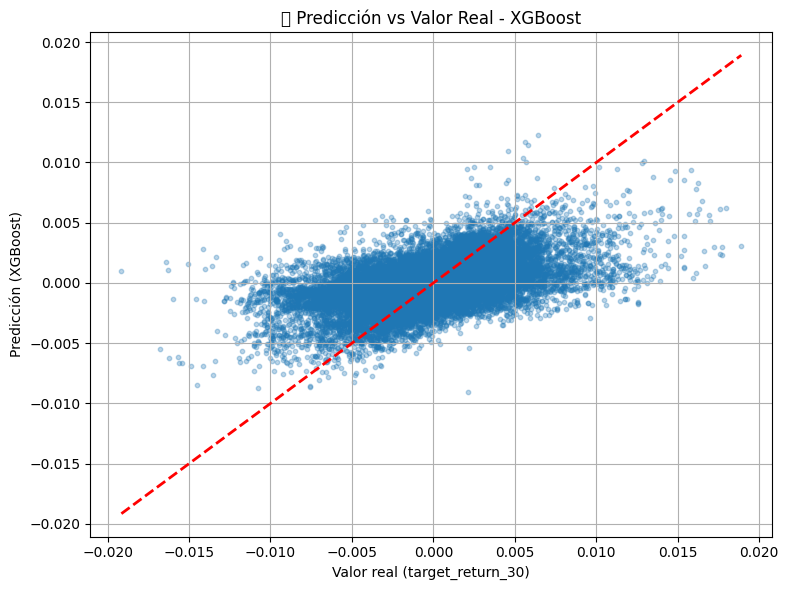

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Valor real (target_return_30)")
plt.ylabel("Predicción (XGBoost)")
plt.title("📉 Predicción vs Valor Real - XGBoost")
plt.grid(True)
plt.tight_layout()
plt.show()

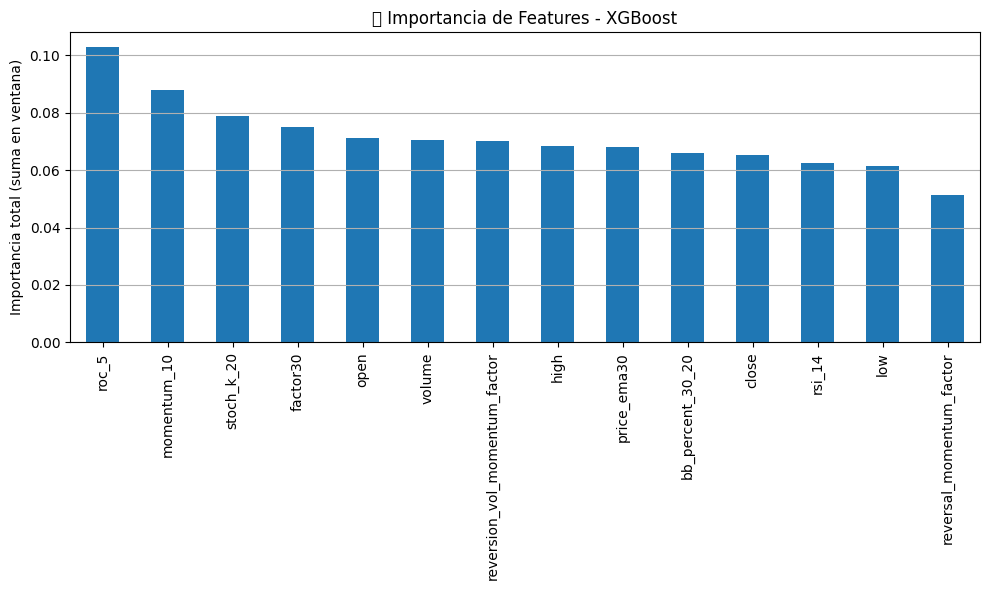

In [38]:
import matplotlib.pyplot as plt
import pandas as pd

# Lista de features originales (14 columnas usadas en la ventana)
features = [
    'open', 'high', 'low', 'close', 'volume',
    'factor30', 'rsi_14', 'price_ema30', 'reversal_momentum_factor',
    'stoch_k_20', 'bb_percent_30_20', 'reversion_vol_momentum_factor',
    'momentum_10', 'roc_5'
]

n = 30  # tamaño de la ventana
importancias = modelo_xgb.feature_importances_

# Sumar importancias de cada feature a lo largo de la ventana
importancia_por_feature = pd.Series(
    [importancias[i*n:(i+1)*n].sum() for i in range(len(features))],
    index=features
).sort_values(ascending=False)

# Graficar
plt.figure(figsize=(10, 6))
importancia_por_feature.plot(kind='bar')
plt.title("📊 Importancia de Features - XGBoost")
plt.ylabel("Importancia total (suma en ventana)")
plt.grid(axis='y')
plt.tight_layout()
plt.show()